# DAAAnalyzer_5.0_BatchAnalysis_ThresholdShiftCalc.ipynb
Created by: JFranco | Created On: 26 JAN 2025 | Last Env: QISHA | Last Run Date: 26 JAN 2025

This Python notebook analyzes the threshold shift and changes in wave one amplitudes between two time points. 
It generates a .csv file that has the calculated DPOAE and ABR threshold shifts for each animal, and then 
descriptive statistics between groups. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
# Parameters for plotting
conditions = ["Pink","Blue","NonInj"]
pltOrder = conditions
colors = {pltOrder[0]:'mediumorchid',pltOrder[1]:'slateblue', pltOrder[2]:'black'}
legColors = ["mediumorchid","slateblue",'black']

In [3]:
# *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
batchID = 'AAVHABclw_CMI_NIHL_2025'
prepIDs = ['CMI_008','CMI_009','CMI_010']
shift ='1to3'        
daaTypes = ['Baseline','2W Post Noise Exposure']
daaRuns = ['1','3']        # For calculating a threshold shift between runs

# Directories 
#   - Existing ones - 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/DAA/'
dirBatch = dirMain+'BatchAnalysis/'+batchID+'/'
dirCMs = dirBatch+"Results/1_CompiledMeasurements/"
dirPltDP = dirBatch+"Results/2_PlotsDPOAEs/"
dirPltABR = dirBatch+"Results/3_PlotsABRs/"
dirPltWO = dirBatch+"Results/4_PlotsWaveOne/"


# Filenames
#    - Existing ones -
fnBaseDPs = '.DPOAEThresholdShifts'
fnBaseABRs = '.ABRThresholdShifts'

#    - Ones that will be made - 
fnDPShifts = batchID+'.DPOAEThresholdShifts.csv'
fnABRShifts = batchID+'.ABRThresholdShifts.csv'

In [4]:
#    *** LOAD THRESHOLD SHIFT SHEETS **
dfDPSs = pd.DataFrame()
dfABRSs = pd.DataFrame()
for prepID in prepIDs:
    dirDFs = dirMain+prepID+'/Results/1_CompiledMeasurements/'
    dfDP = pd.read_csv(dirDFs+prepID+fnBaseDPs+'.csv')
    dfABR = pd.read_csv(dirDFs+prepID+fnBaseABRs+'.csv')
    dfDPSs = pd.concat([dfDPSs, dfDP])
    dfABRSs = pd.concat([dfABRSs, dfABR])
dfDPSs.drop(['Unnamed: 0'], axis=1, inplace=True)
dfABRSs.drop(['Unnamed: 0'], axis=1, inplace=True)

dfDPSs.to_csv(dirCMs+fnDPShifts)
dfABRSs.to_csv(dirCMs+fnABRShifts)

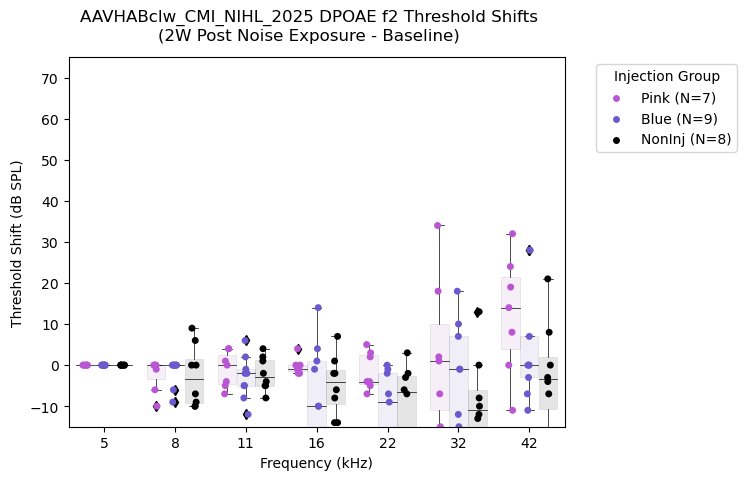

In [5]:
# *** PLOT DPOAE f2 THRESHOLD SHIFTS ***
plot = "DPOAEf2ThresholdShifts.Shift_"+shift
plottype = "BoxStrip"
title = batchID+" DPOAE f2 Threshold Shifts\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'f2Freq_kHz'
data = dfDPSs
y='Shift_1to2'
xlab = "Frequency (kHz)"
ylab ="Threshold Shift (dB SPL)"
ymin = -15
ymax = 75
savLoc = dirPltDP

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(dirPltDP+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

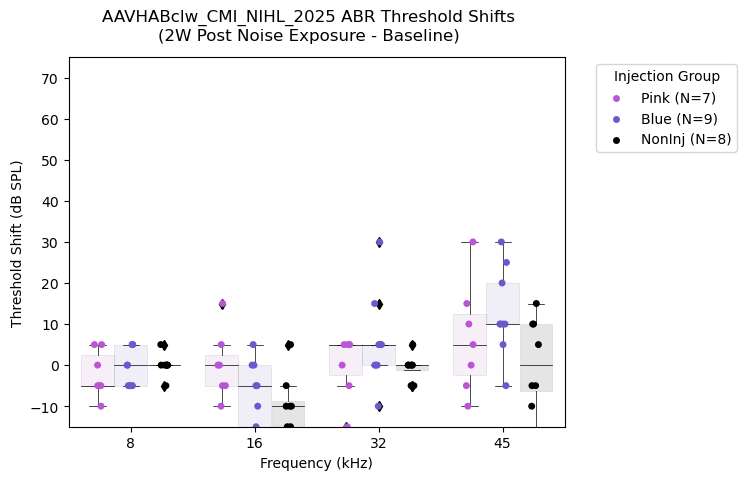

In [6]:
# *** PLOT ABR THRESHOLD SHIFTS ***
plot = "ABRThresholdShifts.Shift_"+str(daaRuns[0])+"."+shift
plottype = "BoxStrip"
title = batchID+" ABR Threshold Shifts\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'Freq_kHz'
data = dfABRSs
y='Shift_1to2'
xlab = "Frequency (kHz)"
ylab ="Threshold Shift (dB SPL)"
ymin = -15
ymax = 75
savLoc = dirPltABR

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(dirPltDP+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')

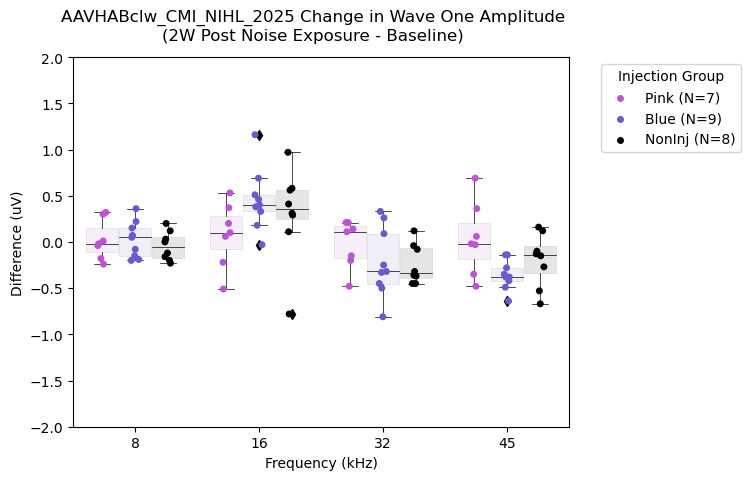

In [7]:
# *** PLOT CHANGE IN WAVE ONE AMPLITUDES ***
plot = "ChangeInWaveOneAmp.Shift_"+shift
plottype = "BoxStrip"
title = batchID+" Change in Wave One Amplitude\n("+daaTypes[1]+' - '+daaTypes[0]+')'
hue = 'InjGroup'
x = 'Freq_kHz'
data = dfABRSs
y='W1Change_1to2_uV'
xlab = "Frequency (kHz)"
ylab ='Difference (uV)'
ymin = -2
ymax = 2
savLoc = dirPltWO

# *** MAKE PLOT ***
fig, ax = plt.subplots()

# Set the title of the figure
fig.suptitle(title)

# Setup the plot
ax1 = sns.stripplot(data=data,x=x,y=y, hue=hue,palette=colors,legend = False, dodge = True, jitter=True)
sns.boxplot(data=data,x=x,y=y, hue=hue,palette=colors,boxprops={'alpha': 0.1}, ax=ax1, dodge = True,linewidth=.5)
ax1.set_ylim((ymin, ymax))
ax1.set(xlabel=xlab)
ax1.set(ylabel=ylab)
ax1.get_legend().remove()

# *~Set up legend~*
labels =[]
for i in range(len(conditions)):
    label = conditions[i]+' (N='+str(len(data[data['InjGroup']==conditions[i]]['AnimalID'].unique()))+')',
    labels.append(label[0])
    
plt.legend(title='Injection Group', bbox_to_anchor=(1.05, 1), loc='upper left',  fancybox=True, labels=labels)
leg = ax1.get_legend()
noHandles = len(leg.legend_handles)
i=0
for i in range(0, noHandles):
    leg.legend_handles[i].set_color(legColors[i])
    
plt.savefig(dirPltWO+batchID+'.'+plot+'.'+plottype+'.png',  bbox_inches='tight', dpi = 300,format = 'png')